# Input av område av Sverige och typ av analys nedan

## --------------------------------------------------
## **Områdesnamn och utsträckning av analys**
## *location_name:* Filerna som skapas kommer att döpas med namnet som skrivs in
## *west:* Longituden av den västra kanten av området som du vill analysera
## *south:* Latituden av den södra kanten av området som du vill analysera
## *east:* Longituden av den östra kanten av området som du vill analysera
## *north:* Latituden av den norra kanten av området som du vill analysera

In [1]:
# location_name = "Lidköping"
# west = 388684
# south = 6482528
# east = 400896
# north = 6487898

# location_name = "Skövde"
# west = 423791
# south = 6465143
# east = 445099
# north = 6483192

# location_name = "Södertälje"
# west = 646098
# south = 6558338
# east = 667691
# north = 6572800

location_name = "Järfälla"
west = 655869
south = 6585172
east = 664546
north = 6597336

# location_name = "Halmstad"
# west = 360010
# south = 6277153
# east = 376412
# north = 6287090

# location_name = "Sundsvall"
# west = 606189
# south = 6915858
# east = 627638
# north = 6928922

# location_name = "Botkyrka"
# west = 659740
# south = 6568885
# east = 663760
# north = 6572546

# location_name = "Kungälv"
# west = 315478
# south = 6411720
# east = 332739
# north = 6429062

# location_name = "Kungsbacka"
# west = 313666
# south = 6354733
# east = 331748
# north = 6384115

## **Settings**
## *AI: Vill du använda AI (Gemini), eller en snabbare algorithm som oftast har okej precision?*
## *Compute_current_BTA: Vill du ladda ner ett punktmoln för få en precis uppskattning av den befintliga bruttoarean av detaljplanen?*
## Skriv "True" eller "False", (om osäker välj False)

In [2]:
AI_gemini = False
compute_current_BTA = True

## --------------------------------------------------
## *Inga mer input förväntas under denna kommentaren*

# Imports

In [3]:
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from PIL import Image
from io import BytesIO
import rasterio
import json
from urllib.parse import urlparse, parse_qs

import matplotlib.pyplot as plt
import os
import google.generativeai as genai
import re

from shapely.geometry import Polygon, box
import dtcc
from pathlib import Path

import time
from pyproj import Transformer

from keplergl import KeplerGl
import ipywidgets as widgets

from dotenv import load_dotenv
load_dotenv()

2025-08-26 09:10:47,455 [dtcc io2] [WARNING] Unable to find pyassimp, some file formats will not be supported
2025-08-26 09:10:47,740 [root] [WARNING] <function default_view at 0x000002044C924CC0> Method view already exists, replacing it.
2025-08-26 09:10:47,740 [root] [WARNING] <function default_view at 0x000002044C924CC0> Method view already exists, replacing it.
2025-08-26 09:10:47,740 [root] [WARNING] <function default_view at 0x000002044C924CC0> Method view already exists, replacing it.
2025-08-26 09:10:47,740 [root] [WARNING] <function default_view at 0x000002044C924CC0> Method view already exists, replacing it.
2025-08-26 09:10:47,745 [root] [WARNING] <function default_view at 0x000002044C924CC0> Method view already exists, replacing it.


True

# Analysis

### access key from lantmäteriets API

In [4]:
bbox = [west, south, east, north]

KT_client_id = os.getenv("K&T_CLIENT_ID")
KT_client_secret = os.getenv("K&T_CLIENT_SECRET")

KT_client_id2 = os.getenv("K&T_CLIENT_ID2")
KT_client_secret2 = os.getenv("K&T_CLIENT_SECRET2")

token_url = "https://apimanager.lantmateriet.se/oauth2/token"
data = {"grant_type": "client_credentials"}

response = requests.post(token_url, data=data, auth=requests.auth.HTTPBasicAuth(KT_client_id, KT_client_secret)).json()
access_token_KT1 = response.get("access_token")

response = requests.post(token_url, data=data, auth=requests.auth.HTTPBasicAuth(KT_client_id2, KT_client_secret2)).json()
access_token_KT2 = response.get("access_token")

def fetch_plans(base_url, payload, headers, json_response=False, crs="EPSG:3006"):
    all_features = []
    all_responses = []
    after_id = None

    while True:
        request_url = f"{base_url}?afterId={after_id}" if after_id else base_url
        response = requests.post(request_url, json=payload, headers=headers).json()

        if json_response:
            all_responses.append(response)

        if 'features' in response:
            all_features.extend(response['features'])
        else:
            break

        next_link = next((link for link in response.get('links', []) if link.get('rel') == 'next'), None)
        if next_link:
            parsed_url = urlparse(next_link['href'])
            after_id_param = parse_qs(parsed_url.query).get('afterId', [None])[0]
            if after_id_param:
                after_id = after_id_param
            else:
                break
        else:
            break

    gdf = gpd.GeoDataFrame.from_features(all_features, crs=crs) if all_features else gpd.GeoDataFrame(columns=['geometry'], crs=crs)

    if json_response:
        return gdf, all_responses
    else:
        return gdf


### Fetch zooning plan, (Detaljplan)

In [5]:
payload = {
    "query": {
            "feature.typ": {"eq": "detaljplan"},
            "detaljplan.status": {"in": ["laga kraft"]},
        },
    "limit": 10000,
    "bbox": bbox
}

url = "https://api.lantmateriet.se/distribution/geodatakatalog/sokning/v1/detaljplan/v2/search"
headers = {
    "Authorization": f"Bearer {access_token_KT2}",
    "Content-Type": "application/json",
}

gdf_detaljplan = fetch_plans(url, payload, headers)

### Fetch zooning plan, (Användningsbestämmelser)

In [6]:
payload = {
    "query": {
            "feature.typ": {"eq": "användningsbestämmelse"},
            "planbestammelse.kategori": {"in": ["Bostäder", "Industri", "Verksamheter", "Skola"]},
            "detaljplan.status": {"in": ["laga kraft"]},
        },
    "limit": 10000,
    "bbox": bbox
}

url = "https://api.lantmateriet.se/distribution/geodatakatalog/sokning/v1/detaljplan/v2/search"
headers = {
    "Authorization": f"Bearer {access_token_KT2}",
    "Content-Type": "application/json",
}

gdf_anvandningsbestammelse, response_anvandningsbestammelse = fetch_plans(url, payload, headers, json_response=True)


### Fetch zooning plan, (Egenskapsbestämmelser)

In [7]:
payload1 = {
    "query": {
            "feature.typ": {"eq": "egenskapsbestämmelse"},
            "planbestammelse.kategori": {"in": ["Omfattning"]},
            "planbestammelse.underkategori": {"in": ["Höjd på byggnader", "Utnyttjandegrad", "Begränsning av markens utnyttjande"]},
            "detaljplan.status": {"in": ["laga kraft"]},
        },
    "limit": 10000,
    "bbox": bbox
}

payload2 = {
    "query": {
            "feature.typ": {"eq": "egenskapsbestämmelse"},
            "planbestammelse.kategori": {"in": ["Höjd på byggnadsverk", "Utnyttjandegrad", "Begränsning av markens utnyttjande"]},
            "detaljplan.status": {"in": ["laga kraft"]},
        },
    "limit": 10000,
    "bbox": bbox
}

url = "https://api.lantmateriet.se/distribution/geodatakatalog/sokning/v1/detaljplan/v2/search"
headers = {
    "Authorization": f"Bearer {access_token_KT2}",
    "Content-Type": "application/json",
}

gdf_egenskapsbestammelse_omfattning = fetch_plans(url, payload1, headers)
gdf_egenskapsbestammelse = fetch_plans(url, payload2, headers)

In [8]:
print(len(gdf_detaljplan))
print(len(gdf_anvandningsbestammelse))
print(len(gdf_egenskapsbestammelse_omfattning))
print(len(gdf_egenskapsbestammelse))

487
1657
51
12532


### Fetch elevation of detail plans

In [9]:
coords_proj = [(point.x, point.y) for point in gdf_detaljplan['geometry'].centroid]

transformer = Transformer.from_crs("EPSG:32633", "EPSG:4326", always_xy=True)
locations = [transformer.transform(x, y)[::-1] for x, y in coords_proj]

url = "https://api.opentopodata.org/v1/eudem25m"
batch_size = 100
elevations = []

for i in range(0, len(locations), batch_size):
    batch = locations[i:i + batch_size]
    locations_str = "|".join([f"{lat},{lon}" for lat, lon in batch])
    params = {"locations": locations_str}

    response = requests.get(url, params=params)

    if response.status_code == 429:
        print("Rate limit reached. Sleeping for 5 seconds...")
        time.sleep(5)
        response = requests.get(url, params=params)

    response.raise_for_status()
    data = response.json()

    for elevation in data["results"]:
        elevations.append(elevation["elevation"])

    time.sleep(0.5)

gdf_detaljplan['elevation'] = [round(elevation, 1) if elevation is not None else 0 for elevation in elevations]

### Sort the egenskapsbestämmelser into categories "Utnyttjandegrad" and "Höjd på byggnader"

In [10]:
# Insert columns objektidentitet and area
gdf_detaljplan['Objektidentitet'] = gdf_detaljplan['detaljplan'].apply(lambda d: d.get('objektidentitet'))
gdf_egenskapsbestammelse['Objektidentitet'] = (gdf_egenskapsbestammelse.get('detaljplan',
        pd.Series([None]*len(gdf_egenskapsbestammelse))).apply(lambda x: x.get('objektidentitet') if isinstance(x, dict) else None))
gdf_egenskapsbestammelse_omfattning['Objektidentitet'] = (gdf_egenskapsbestammelse_omfattning.get('detaljplan',
        pd.Series([None]*len(gdf_egenskapsbestammelse_omfattning))).apply(lambda x: x.get('objektidentitet') if isinstance(x, dict) else None))

gdf_egenskapsbestammelse['area'] = gdf_egenskapsbestammelse['geometry'].area
gdf_egenskapsbestammelse_omfattning['area'] = gdf_egenskapsbestammelse_omfattning['geometry'].area

# Begränsning av markens utnyttjande
begransning_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse.get('planbestammelse', []))
        if item.get('kategori') is not None and item.get('kategori') == 'Begränsning av markens utnyttjande']
begransning = gdf_egenskapsbestammelse.iloc[begransning_mask]

begransning_omfattning_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse_omfattning.get('planbestammelse', []))
        if item.get('underkategori') is not None and item.get('underkategori') == 'Begränsning av markens utnyttjande']
begransning_omfattning = gdf_egenskapsbestammelse_omfattning.iloc[begransning_omfattning_mask]
gdf_begransning_byggnad = gpd.GeoDataFrame(pd.concat([begransning, begransning_omfattning], ignore_index=True))

# Utnyttjandegrad
utnyttjande_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse.get('planbestammelse', []))
        if item.get('kategori') is not None and item.get('kategori') == 'Utnyttjandegrad']
utnyttjande = gdf_egenskapsbestammelse.iloc[utnyttjande_mask]

utnyttjande_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse_omfattning.get('planbestammelse', []))
        if item.get('underkategori') is not None and item.get('underkategori') == 'Utnyttjandegrad']
utnyttjande_omfattning = gdf_egenskapsbestammelse_omfattning.iloc[utnyttjande_mask]
utnyttjande = gpd.GeoDataFrame(pd.concat([utnyttjande, utnyttjande_omfattning], ignore_index=True))

utnyttjande_mask = [i for i, item in enumerate(utnyttjande.get('planbestammelse', []))
        if item.get('bestammelsevarde') is not None and item.get('bestammelsevarde').get('enhet') in ['kvadratmeter', 'procent']]
utnyttjande_uncategorized = utnyttjande.drop(utnyttjande.index[utnyttjande_mask])
utnyttjande = utnyttjande.iloc[utnyttjande_mask]

# Höjd på byggnader
höjd_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse.get('planbestammelse', []))
        if item.get('kategori') is not None and item.get('kategori') == 'Höjd på byggnadsverk']
höjd = gdf_egenskapsbestammelse.iloc[höjd_mask]

höjd_mask = [i for i, item in enumerate(gdf_egenskapsbestammelse_omfattning.get('planbestammelse', []))
        if item.get('underkategori') is not None and item.get('underkategori') == 'Höjd på byggnader']
omfattning_höjd = gdf_egenskapsbestammelse_omfattning.iloc[höjd_mask]
höjd = gpd.GeoDataFrame(pd.concat([höjd, omfattning_höjd], ignore_index=True))

höjd_mask = [i for i, item in enumerate(höjd.get('planbestammelse', []))
        if item.get('bestammelsevarde') is not None and item.get('bestammelsevarde').get('enhet') in ['meter', 'antal']]
höjd_uncategorized = höjd.drop(höjd.index[höjd_mask])
höjd = höjd.iloc[höjd_mask]


### Use RegEx to categorise the uncategorised egenskapsbestämmelser

In [11]:
# # Allows for optional surrounding context, captures the number itself.
# number_pattern = re.compile(r"(\d+(?:[.,]\d+)?)", re.IGNORECASE)

# # Pattern to check for the presence of meter units (using word boundaries)
# meter_unit_pattern = re.compile(r"\b(meter|m)\b", re.IGNORECASE)

# # Pattern to find any floor number
# floor_number_pattern = re.compile(r"\b(\d+)\b", re.IGNORECASE)

# # Pattern to check for the presence of floor units (using word boundaries)
# floor_unit_pattern = re.compile(r"\b(våning|våningar)\b", re.IGNORECASE)


# def normalize_number_value(num_str):
#     """Converts a string number (potentially with comma) to float or int."""
#     if not num_str:
#         return None
#     try:
#         value = float(num_str.replace(',', '.'))
#         return int(value) if value.is_integer() else value
#     except ValueError:
#         return None


# def normalize_floor_number_value(floor_num_str):
#     """Converts floor number string ('en' or digits) to int."""
#     if not floor_num_str:
#         return None
#     try:
#         return int(floor_num_str)
#     except ValueError:
#         return None


# def extract_simplified_presence_check(rule_string):
#     """
#     Checks for presence of number & meter OR floor_num & floor_unit.
#     Extracts the *first* number found that matches the criteria.
#     Returns {"value": num, "enhet": "meter"/"antal"} or None.
#     """
#     # Find first number match object
#     first_number_match = number_pattern.search(rule_string)
#     # Find first floor number match object (could be same as number_match)
#     first_floor_number_match = floor_number_pattern.search(rule_string)

#     # Check for presence of units
#     meter_unit_found = meter_unit_pattern.search(rule_string) is not None
#     floor_unit_found = floor_unit_pattern.search(rule_string) is not None

#     # --- Apply Prioritized Logic ---
#     # Check for Number + Meter combination
#     if first_number_match and meter_unit_found:
#         num_value = normalize_number_value(first_number_match.group(1))
#         if num_value is not None:
#             return {"variabelvarde": num_value, "enhet": "meter"}

#     # Check for Floor Number + Floor Unit combination
#     elif first_floor_number_match and floor_unit_found:
#         floor_num_value = normalize_floor_number_value(first_floor_number_match.group(1))
#         if floor_num_value is not None:
#              # Avoid extracting simple numbers if they look like part of a meter value we missed
#              # Example: In "3.5 meter", floor_number finds "3", but we prefer the meter match if possible.
#              # This check helps slightly if the meter normalization failed for some reason.
#              # A more robust check might be needed depending on edge cases.
#              potential_meter_context = meter_unit_pattern.search(rule_string[first_floor_number_match.end():first_floor_number_match.end()+10]) # Check shortly after
#              if not potential_meter_context: # If 'meter' isn't immediately after, assume it's a floor count
#                  return {"variabelvarde": floor_num_value, "enhet": "antal"}

#     return None

# rules_höjd = [item['bestammelseformulering'] for item in höjd_uncategorized['planbestammelse']]

# # Run the extraction
# extracted_results_simplified = [extract_simplified_presence_check(rule) for rule in rules_höjd]

# # Print the results
# print("\n--- Simplified Presence Check Results ---")
# success_count_simplified = 0
# for i, result in enumerate(extracted_results_simplified):
#     status = "Success" if result else "Failed"
#     if result:
#         success_count_simplified += 1
#     # Shorten long rules for display
#     display_rule = rules_höjd[i]
#     print(f"Rule {i:>3}: {status:<10} -> {result if result else np.nan}")
#     print(f"      Original: {display_rule}") # Uncomment to see original rule
#     print("-" * 30)

# print(f"\nSuccessfully extracted data (simplified logic) for {success_count_simplified} out of {len(rules_höjd)} rules.")

# # Optional: Full JSON output
# # print("\nFinal list (JSON format):")
# # print(json.dumps(extracted_results_simplified, indent=2, ensure_ascii=False))

# # Add the categories to the bestämmelser
# for i, item in enumerate(höjd_uncategorized['planbestammelse']):
#     item['bestammelsevarde'] = extracted_results_simplified[i]

In [12]:
# --- REGEX PATTERNS ---
number_pattern = re.compile(r"(\d+(?:[.,]\d+)?)", re.IGNORECASE)
meter_unit_pattern = re.compile(r"\b(meter|m)\b", re.IGNORECASE)
floor_unit_pattern = re.compile(r"\b(våning|våningar)\b", re.IGNORECASE)

# Pattern to find Roman numerals (I, V, X, L, C, D, M) using word boundaries
roman_numeral_pattern = re.compile(r"\b([IVXLCDM]+)\b", re.IGNORECASE)


# --- HELPER FUNCTIONS ---
def roman_to_int(s):
    """Converts a Roman numeral string to an integer."""
    if not s:
        return None
    
    s = s.upper()
    roman_map = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
    result = 0
    try:
        for i in range(len(s)):
            # Handle subtractive notation like IV (4) and IX (9)
            if i > 0 and roman_map[s[i]] > roman_map[s[i-1]]:
                result += roman_map[s[i]] - 2 * roman_map[s[i-1]]
            else:
                result += roman_map[s[i]]
        return result
    except (KeyError, TypeError):
        return None


def normalize_number_value(num_str):
    """Converts a string number (potentially with comma) to float or int."""
    if not num_str:
        return None
    try:
        value = float(num_str.replace(',', '.'))
        return int(value) if value.is_integer() else value
    except ValueError:
        return None


# --- EXTRACTION FUNCTION ---
def extract_height_data(rule_string):
    """
    Extracts height data, prioritizing meter values, then floor counts
    (handling both Arabic and Roman numerals).
    Returns {"variabelvarde": num, "enhet": "meter"/"antal"} or None.
    """
    # Check for presence of units first
    meter_unit_found = meter_unit_pattern.search(rule_string) is not None
    floor_unit_found = floor_unit_pattern.search(rule_string) is not None

    # --- Apply Prioritized Logic ---
    # 1. Highest Priority: Number + Meter combination
    if meter_unit_found:
        number_match = number_pattern.search(rule_string)
        if number_match:
            num_value = normalize_number_value(number_match.group(1))
            if num_value is not None:
                return {"variabelvarde": num_value, "enhet": "meter"}

    # 2. Next Priority: Floor Number + Floor Unit combination
    elif floor_unit_found:
        # First, try to find a standard Arabic numeral (e.g., "2")
        digit_match = re.search(r"\b(\d+)\b", rule_string)
        if digit_match:
            num_value = normalize_number_value(digit_match.group(1))
            if num_value is not None:
                return {"variabelvarde": num_value, "enhet": "antal"}
        
        # If no digit is found, try to find a Roman numeral (e.g., "II")
        roman_match = roman_numeral_pattern.search(rule_string)
        if roman_match:
            num_value = roman_to_int(roman_match.group(1))
            if num_value is not None:
                return {"variabelvarde": num_value, "enhet": "antal"}
                
    return None

rules_höjd = [item['bestammelseformulering'] for item in höjd_uncategorized['planbestammelse']]

# Run the extraction
extracted_results = [extract_height_data(rule) for rule in rules_höjd]

# Print the results
print("--- Extraction Results with Roman Numeral Support ---")
success_count = 0
for i, result in enumerate(extracted_results):
    status = "Success" if result else "Failed"
    if result:
        success_count += 1
    display_rule = rules_höjd[i]
    print(f"Rule {i:>3}: {status:<10} -> {result if result else 'None'}")
    print(f"       Original: {display_rule}")
    print("-" * 40)

print(f"\nSuccessfully extracted data for {success_count} out of {len(rules_höjd)} rules.")

# # Optional: Full JSON output
# print("\nFinal list (JSON format):")
# print(json.dumps(extracted_results, indent=2, ensure_ascii=False))

# Add the categories to the bestämmelser
for i, item in enumerate(höjd_uncategorized['planbestammelse']):
    item['bestammelsevarde'] = extracted_results[i]

--- Extraction Results with Roman Numeral Support ---
Rule   0: Success    -> {'variabelvarde': 66.515, 'enhet': 'meter'}
       Original: Högsta totalhöjd är 66.515 meter över angivet nollplan
----------------------------------------
Rule   1: Success    -> {'variabelvarde': 3.5, 'enhet': 'meter'}
       Original: Högsta byggnadshöjd är 3.5 meter
----------------------------------------
Rule   2: Success    -> {'variabelvarde': 25.515, 'enhet': 'meter'}
       Original: Högsta byggnadshöjd är +25.515 meter över nollplanet
----------------------------------------
Rule   3: Success    -> {'variabelvarde': 3, 'enhet': 'meter'}
       Original: Högsta byggnadshöjd är 3.0 meter
----------------------------------------
Rule   4: Success    -> {'variabelvarde': 9, 'enhet': 'meter'}
       Original: Högsta byggnadshöjd är 9 meter. Gäller även skyltar
----------------------------------------
Rule   5: Success    -> {'variabelvarde': 2.5, 'enhet': 'meter'}
       Original: Högsta byggnadshöjd f

In [13]:
# --- 1. Define Regex Patterns (Utnyttjande) ---

# Pattern to find any number (captures the first one found).
# Attempts to handle spaces within digits and comma/dot decimals.
# Relies on normalization function to clean and fully validate.
number_pattern = re.compile(r"(\d[\d\s.,]*)", re.IGNORECASE)

# Pattern to check for the presence of percent units
percent_unit_pattern = re.compile(r"\%|\bprocent\b", re.IGNORECASE)

# Pattern to check for the presence of area units (m2, kvm, etc.)
# Using VERBOSE for readability
area_unit_pattern = re.compile(
    r"""
    \b(kvadratmeter|kvm)\b  # Option 1: Match whole words 'kvadratmeter' or 'kvm'
    |
    # Option 2: Match 'm' followed by variants of '2'
    # Covers: m2, m 2, m>2, m > 2, etc. (Catches 'm>2' part of 'm>2<')
    m\s*(?:>)?\s*2
    |
    m\^2
    |
    # Option 3: Match literal unicode superscript '²' after 'm'
    m²
    """,
    re.IGNORECASE | re.VERBOSE
)

# --- 2. Normalization Helper ---

def normalize_number_value(num_str):
    """
    Converts a string number (potentially with comma/spaces) to float or int.
    Returns None if conversion fails.
    """
    if not num_str: return None
    # Remove spaces (like thousands separators) and standardize decimal point
    # Also remove potential trailing non-numeric noise captured by the broad pattern
    cleaned_num_str = num_str.strip().replace(' ', '').replace(',', '.')
    try:
        # Validate structure more strictly after cleaning (digits, optional dot, digits)
        # Use re.match to ensure it starts correctly and extract the valid part
        match = re.match(r"^\d+(\.\d+)?", cleaned_num_str)
        if not match:
             return None # Doesn't look like a number after cleaning
        valid_num_part = match.group(0)
        value = float(valid_num_part)
        # Convert to int if it represents a whole number (e.g., 1200.0 -> 1200)
        return int(value) if value.is_integer() else value
    except (ValueError, AttributeError):
        # Handle cases where float() fails or re.match returns None
        return None

# --- 3. Processing Function (Utnyttjande - Simplified Logic) ---

def extract_utnyttjande_simplified(rule_string):
    """
    Checks for presence of number & percent unit OR number & area unit.
    Extracts the *first* number found that matches the criteria.
    Prioritizes percent over area.
    Returns {"value": num, "unit": "procent"/"kvadratmeter"} or None.
    """
    # Basic checks for invalid input or obvious placeholders
    if not isinstance(rule_string, str) or not rule_string.strip() or rule_string.strip().startswith('['):
        return None

    first_number_match = number_pattern.search(rule_string)
    percent_unit_found = percent_unit_pattern.search(rule_string) is not None
    area_unit_found = area_unit_pattern.search(rule_string) is not None

    # --- Apply Prioritized Logic ---
    if first_number_match:
        # Extract and normalize the first number found
        num_value = normalize_number_value(first_number_match.group(1))

        if num_value is not None:
            # Priority 1: Check for Number + Percent combination
            if percent_unit_found:
                return {"variabelvarde": num_value, "enhet": "procent"}

            # Priority 2: Check for Number + Area combination
            elif area_unit_found:
                return {"variabelvarde": num_value, "enhet": "kvadratmeter"}

    return None

rules_utnyttjande = [item['bestammelseformulering'] for item in utnyttjande_uncategorized['planbestammelse']]

# Run the extraction
extracted_results = [extract_utnyttjande_simplified(rule) for rule in rules_utnyttjande]

# Print the results
print("\n--- Simplified Presence Check Results ---")
success_count_simplified = 0
for i, result in enumerate(extracted_results):
    status = "Success" if result else "Failed"
    if result:
        success_count_simplified += 1
    display_rule = rules_utnyttjande[i]
    print(f"Rule {i:>3}: {status:<10} -> {result if result else np.nan}")
    print(f"      Original: {display_rule}") # Uncomment to see original rule
    print("-" * 30)

print(f"\nSuccessfully extracted data (simplified logic) for {success_count_simplified} out of {len(rules_utnyttjande)} rules.")

# Optional: Full JSON output
# print("\nFinal list (JSON format):")
# print(json.dumps(extracted_results, indent=2, ensure_ascii=False))

# Add the categories to the bestämmelser
for i, item in enumerate(utnyttjande_uncategorized['planbestammelse']):
    item['bestammelsevarde'] = extracted_results[i]



--- Simplified Presence Check Results ---
Rule   0: Success    -> {'variabelvarde': 1000, 'enhet': 'kvadratmeter'}
      Original: Största byggnadsarea är 1000 m²
------------------------------
Rule   1: Success    -> {'variabelvarde': 25, 'enhet': 'procent'}
      Original: Största byggnadsarea är 25 % av fastighetsarean inom användningsområdet
------------------------------
Rule   2: Success    -> {'variabelvarde': 50, 'enhet': 'kvadratmeter'}
      Original: Största byggnadsarea för komplementbyggnad är 50 kvm
------------------------------
Rule   3: Success    -> {'variabelvarde': 100, 'enhet': 'procent'}
      Original: Största bruttoarea är 100 % av fastighetsarean inom användningsområdet
------------------------------
Rule   4: Success    -> {'variabelvarde': 13000, 'enhet': 'kvadratmeter'}
      Original: Största sammanlagda bruttoarea för huvudbyggnader ovan mark är 13000 m². Bruttoarea för underbyggda gårdar, parkeringsgarage och inglasade balkonger räknas inte in i bestämme

### Update the categorized bestämmelser

In [14]:
höjd_mask = [i for i, item in enumerate(höjd_uncategorized['planbestammelse']) if item['bestammelsevarde'] is not None]
höjd_regex = höjd_uncategorized.iloc[höjd_mask]
höjd = gpd.GeoDataFrame(pd.concat([höjd, höjd_regex], ignore_index=True))
höjd_uncategorized = höjd_uncategorized.drop(höjd_uncategorized.index[höjd_mask])

utnyttjande_mask = [i for i, item in enumerate(utnyttjande_uncategorized['planbestammelse']) if item['bestammelsevarde'] is not None]
utnyttjande_regex = utnyttjande_uncategorized.iloc[utnyttjande_mask]
utnyttjande = gpd.GeoDataFrame(pd.concat([utnyttjande, utnyttjande_regex], ignore_index=True))
utnyttjande_uncategorized = utnyttjande_uncategorized.drop(utnyttjande_uncategorized.index[utnyttjande_mask])

In [15]:
print(f"Höjd unextracted: {len(höjd_uncategorized)}")
print(f"Höjd extracted: {len(höjd)}")
print(f"utnyttjande unextracted: {len(utnyttjande_uncategorized)}")
print(f"utnyttjande extracted: {len(utnyttjande)}")

Höjd unextracted: 15
Höjd extracted: 6182
utnyttjande unextracted: 450
utnyttjande extracted: 1785


## AI

### Display rule data

In [16]:
# [item.get('bestammelseformulering') for item in höjd_uncategorized.get('planbestammelse', [])]
# [item.get('bestammelseformulering') for item in utnyttjande_uncategorized.get('planbestammelse', [])]

### Use LLM to categorize the uncategorised egenskapsbestämmelser

In [17]:
if not AI_gemini:
    print("skipping AI classifications...")
else:
    genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))
    # model = genai.GenerativeModel(model_name="gemini-1.5-pro-latest")
    # model = genai.GenerativeModel(model_name="gemini-2.0-flash")
    # model = genai.GenerativeModel(model_name="gemini-2.5-flash-preview-05-06")
    # model = genai.GenerativeModel(model_name="gemini-2.5-flash-preview-05-20")
    model = genai.GenerativeModel(model_name="gemini-2.5-flash")

    # --- HEIGHT ---
    rules_höjd = [item.get('bestammelseformulering', '') for item in höjd_uncategorized.get('planbestammelse', [])][:]

    regulations_höjd = {
        "type": "object",
        "properties": {
            "variabelvarde": {
                "description": "Infoga variabelvarde här.",
                "type": "number"
            },
            "enhet": {
                "description": "Infoga enhet här.",
                "type": "string",
                "enum": ["meter", "antal"]
            }
        },
        "required": ["variabelvarde", "enhet"]
    }

    prompt_höjd = (
        "Du är en expert på byggregler och förstår konsekvent regelverk kring byggnadshöjd.\n"
        "Indatan består av en lista med regler. Du måste returnera ett JSON-objekt för varje regel i indatan.\n"
        "Om en regel inte kan tolkas eller inte innehåller både enhet och variabelvarde, returnera None för den regeln.\n\n"
        "Indata (regler):\n"
        f"{rules_höjd}\n\n"
        "Varje JSON-objekt måste matcha följande schema:\n"
        f"{json.dumps(regulations_höjd, indent=2)}\n\n"
        "Returnera endast listan med JSON-objekt, varje objekt i listan måste vara ett JSON-objekt med en enhet och ett variabelvärde, alternativt None."
    )

    try:
        response_höjd = model.generate_content(prompt_höjd)
        llm_message = re.sub(r"^```json\n|\n```$", "", response_höjd.text.strip())
        höjd_json = json.loads(llm_message)
        # print("Extracted Height JSON:\n", json.dumps(höjd_json, indent=2, ensure_ascii=False))
    except json.JSONDecodeError as e:
        print(f"Error decoding height JSON: {e}")
        print("LLM Raw Response (Height):\n", response_höjd.text)
    except Exception as e:
        print(f"Error during Gemini API call for height: {e}")
        if 'response_height' in locals() and hasattr(response_höjd, 'prompt_feedback') and response_höjd.prompt_feedback.block_reason:
                print(f"Prompt might have been blocked due to: {response_höjd.prompt_feedback.block_reason}")


    # --- UTNYTTJANDE ---
    rules_utnyttjande = [item.get('bestammelseformulering', '') for item in utnyttjande_uncategorized.get('planbestammelse', [])][:]

    regulations_utnyttjande = {
        "type": "object",
        "properties": {
            "variabelvarde": {
                "description": "Infoga variabelvarde här.",
                "type": "number"
            },
            "enhet": {
                "description": "Infoga enhet här.",
                "type": "string",
                "enum": ["kvadratmeter", "procent"]
            }
        },
        "required": ["variabelvarde", "enhet"]
    }

    prompt_utnyttjande = (
        "Du är en expert på byggregler och förstår konsekvent regelverk kring utnyttjandegrad.\n"
        "Indatan består av en lista med regler. Du måste returnera ett JSON-objekt för varje regel i indatan.\n"
        "Om en regel inte kan tolkas eller inte innehåller både enhet och variabelvarde, returnera None för den regeln.\n\n"
        "Indata (regler):\n"
        f"{rules_utnyttjande}\n\n"
        "Varje JSON-objekt i listan måste matcha följande schema:\n"
        f"{json.dumps(regulations_utnyttjande, indent=2)}\n\n"
        "Returnera endast JSON-listan, varje objekt i listan måste vara ett JSON-objekt med en enhet och ett variabelvärde, alternativt None."
    )

    try:
        response_utnyttjande = model.generate_content(prompt_utnyttjande)
        llm_message = re.sub(r"^```json\n|\n```$", "", response_utnyttjande.text.strip())
        utnyttjande_json = json.loads(llm_message)
        # print("Extracted Utnyttjande JSON:\n", json.dumps(utnyttjande_json, indent=2, ensure_ascii=False))
    except json.JSONDecodeError as e:
        print(f"Error decoding utnyttjande JSON: {e}")
        print("LLM Raw Response (Utnyttjande):\n", response_utnyttjande.text) # Show raw text on error
    except Exception as e:
        print(f"Error during Gemini API call for utnyttjande: {e}")
        if 'response_utnyttjande' in locals() and hasattr(response_utnyttjande, 'prompt_feedback') and response_utnyttjande.prompt_feedback.block_reason:
                print(f"Prompt might have been blocked due to: {response_utnyttjande.prompt_feedback.block_reason}")


skipping AI classifications...


In [18]:
if not AI_gemini:
    print("skipping AI classifications...")
else:
    print(f"Amount of height rules to classify: {len(rules_utnyttjande)}")
    print(f"Amount of height rules classified: {len(utnyttjande_json)}")
    print(f"Amount of height rules successfully classified: {len(utnyttjande_json) - utnyttjande_json.count(None)}")

    print(f"Amount of height rules to classify: {len(rules_höjd)}")
    print(f"Amount of height rules classified: {len(höjd_json)}")
    print(f"Amount of height rules successfully classified: {len(höjd_json) - höjd_json.count(None)}")

    if len(rules_utnyttjande) == len(utnyttjande_json):
        for i, item in enumerate(utnyttjande_uncategorized['planbestammelse']):
            if utnyttjande_json[i] != None:
                item['bestammelsevarde'] = utnyttjande_json[i]

    if len(rules_höjd) == len(höjd_json):
        for i, item in enumerate(höjd_uncategorized['planbestammelse']):
            if höjd_json[i] != None:
                item['bestammelsevarde'] = höjd_json[i]

skipping AI classifications...


## Put them in the same dataframe

In [19]:
# Utnyttjandegrad
utnyttjande_kvm = utnyttjande[utnyttjande['planbestammelse']
                                         .apply(lambda x: x.get('bestammelsevarde').get('enhet') == 'kvadratmeter')]
utnyttjande_procent = utnyttjande[utnyttjande['planbestammelse']
                                             .apply(lambda x: x.get('bestammelsevarde').get('enhet') == 'procent')]
bruttoarea = utnyttjande_kvm[utnyttjande_kvm['planbestammelse'].apply(lambda x: "bruttoarea" in x.get('bestammelseformulering'))]
utnyttjande_kvm = utnyttjande_kvm[utnyttjande_kvm['planbestammelse'].apply(lambda x: "per" not in x.get('bestammelseformulering')
                                                                           and "bruttoarea" not in x.get('bestammelseformulering'))]

# Bruttoarea
bruttoarea_per = bruttoarea[bruttoarea['planbestammelse'].apply(lambda x: "per" in x.get('bestammelseformulering'))]
bruttoarea = bruttoarea[bruttoarea['planbestammelse'].apply(lambda x: "per" not in x.get('bestammelseformulering'))]

# Höjd på byggnader
höjd_antal = höjd[höjd['planbestammelse'].apply(lambda x: x.get('bestammelsevarde').get('enhet') == 'antal')]
höjd_meter = höjd[höjd['planbestammelse'].apply(lambda x: x.get('bestammelsevarde').get('enhet') == 'meter')]
höjd_nollplan_meter = höjd_meter[höjd_meter['planbestammelse'].apply(lambda x: "nollplan" in x.get('bestammelseformulering'))]
höjd_meter = höjd_meter[höjd_meter['planbestammelse'].apply(lambda x: "nollplan" not in x.get('bestammelseformulering'))]

# Calculations
# Utnyttjandegrad
utnyttjande_kvm = utnyttjande_kvm.copy()
utnyttjande_procent = utnyttjande_procent.copy()

utnyttjande_kvm['BYA'] = utnyttjande_kvm['planbestammelse'].apply(
    lambda pb: pb.get('bestammelsevarde').get('variabelvarde'))

utnyttjande_procent['BYA'] = utnyttjande_procent.apply(
    lambda row: row.get('planbestammelse', {}).get('bestammelsevarde', {}).get('variabelvarde') * row.get('area') / 100, axis=1)

gdf_utnyttjande = gpd.GeoDataFrame(pd.concat([utnyttjande_kvm, utnyttjande_procent], ignore_index=True))

# Höjd på byggnader
höjd_meter = höjd_meter.copy()
höjd_antal = höjd_antal.copy()

höjd_meter['floors'] = höjd_meter['planbestammelse'].apply(
    lambda pb: max(1, pb.get('bestammelsevarde').get('variabelvarde') // 3))  # 3m per floor

höjd_antal['floors'] = höjd_antal['planbestammelse'].apply(
    lambda pb: max(1, pb.get('bestammelsevarde').get('variabelvarde')))

höjd_meter['floors'] = höjd_meter['planbestammelse'].apply(
    lambda pb: max(1, (pb.get('bestammelsevarde').get('variabelvarde', 0) or 0) // 3))

gdf_elevation = gdf_detaljplan.merge(höjd_nollplan_meter, on='Objektidentitet', suffixes=('_detaljplan', '_höjd'))

if not gdf_elevation.empty:
    gdf_elevation['floors'] = gdf_elevation.apply(
        lambda row: max(1, (row['planbestammelse'].get('bestammelsevarde').get('variabelvarde') - row['elevation']) // 3), axis=1)
else:
    gdf_elevation['floors'] = pd.Series(dtype=int)

floors_by_id = gdf_elevation.groupby('Objektidentitet')['floors'].mean()  # average amount of floors per zooning plan
höjd_nollplan_meter['floors'] = höjd_nollplan_meter['Objektidentitet'].map(floors_by_id)
höjd_nollplan_meter['floors'] = np.floor(höjd_nollplan_meter['floors']).astype('Int64')

gdf_höjd = gpd.GeoDataFrame(pd.concat([höjd_antal, höjd_meter, höjd_nollplan_meter], ignore_index=True))

# Bruttoarea
bruttoarea['BTA'] = bruttoarea['planbestammelse'].apply(lambda x: x.get('bestammelsevarde').get('variabelvarde'))
bruttoarea_per['BTA_per_område'] = bruttoarea_per['planbestammelse'].apply(lambda x: x.get('bestammelsevarde').get('variabelvarde'))

gdf_egenskapsbestammelse = gpd.GeoDataFrame(pd.concat([gdf_utnyttjande, gdf_höjd, bruttoarea, bruttoarea_per], ignore_index=True))


## Select the correct response and extract links och year from the response

In [20]:
response = response_anvandningsbestammelse[0]

gdf_anvandningsbestammelse["Ladda ner plan"] = [resp.get("assets", {}).get("asset-2", {}).get("href") for resp in response["features"]]
gdf_anvandningsbestammelse["Laga kraft"] = gdf_anvandningsbestammelse.apply(lambda x: x.get('detaljplan').get('datumLagakraft')[:4], axis=1)
gdf_anvandningsbestammelse["Kommun"] = gdf_anvandningsbestammelse['providers'].apply(lambda x: x[0].get('name'))

## Remove the plans that consists of a point or a line

In [21]:
gdf_detaljplan = gdf_detaljplan[gdf_detaljplan.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
gdf_detaljplan.reset_index(drop=True, inplace=True)

gdf_anvandningsbestammelse = gdf_anvandningsbestammelse[gdf_anvandningsbestammelse.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
gdf_anvandningsbestammelse.reset_index(drop=True, inplace=True)

gdf_egenskapsbestammelse = gdf_egenskapsbestammelse[gdf_egenskapsbestammelse.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
gdf_egenskapsbestammelse.reset_index(drop=True, inplace=True)

gdf_begransning_byggnad = gdf_begransning_byggnad[gdf_begransning_byggnad.geometry.geom_type.isin(["Polygon", "MultiPolygon"])]
gdf_begransning_byggnad.reset_index(drop=True, inplace=True)

## Exclude the part where exploitation is not allowed, (overlay difference)

In [22]:
gdf = gpd.overlay(gdf_anvandningsbestammelse, gdf_begransning_byggnad, how='difference', keep_geom_type=True)  # important to keep_geom_type

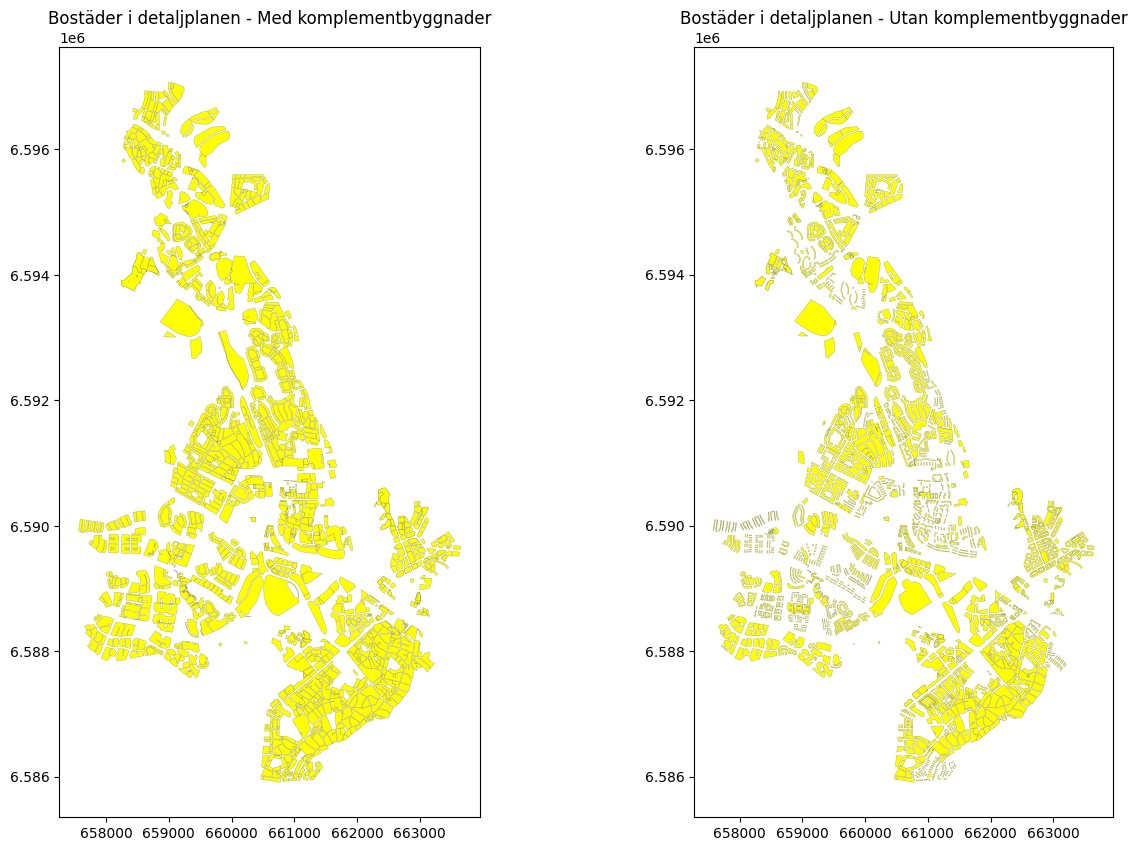

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
gdf_anvandningsbestammelse.plot(ax=ax1, color='yellow', edgecolor='grey', linewidth=0.2)
ax1.set_title("Bostäder i detaljplanen - Med komplementbyggnader")

gdf.plot(ax=ax2, color='yellow', edgecolor='grey', linewidth=0.2)
ax2.set_title("Bostäder i detaljplanen - Utan komplementbyggnader")
plt.show()

## Import map, (DTCC)

### Define bounds

In [24]:
bounding_box = (response["bbox"][0], response["bbox"][1], response["bbox"][2], response["bbox"][3])
bounds = dtcc.Bounds(response["bbox"][0], response["bbox"][1], response["bbox"][2], response["bbox"][3])

### Load map and convert the footprint data to polygons

In [25]:
access_token_KT = ""

In [26]:
# url = "https://api.lantmateriet.se/distribution/produkter/byggnad/v3/schema"
url = "https://api.lantmateriet.se/distribution/produkter/byggnad/v3/search"

# payload = {

#     # "geometri": {
#     #     "type": "Polygon",
#     #     "coordinates": [
#     #     [
#     #         [670000, 6580000],
#     #         [675000, 6580000],
#     #         [675000, 6585000],
#     #         [670000, 6585000],
#     #         [670000, 6580000]
#     #     ]
#     #     ]
#     # }
#     {
#     "geometri": {
#         "type": "Polygon",
#         "crs": {
#         "type": "name",
#         "properties": {
#             "name": "urn:ogc:def:crs:EPSG::3006"
#         }
#         },
#         "coordinates": [
#         [ [618174, 6728548], [618153, 6728423], [618270, 6728395],
#             [618296, 6728525], [618174, 6728548] ]
#         ]
#     },
#     "buffer": 50
#     }
# }

# payload = {
#     {
#     "geometri": {
#         "type": "Polygon",
#         "crs": {
#         "type": "name",
#         "properties": {
#             "name": "urn:ogc:def:crs:EPSG::3006"
#         }
#         },
#         "coordinates": [
#         [ [618174, 6728548], [618153, 6728423], [618270, 6728395],
#             [618296, 6728525], [618174, 6728548] ]
#         ]
#     },
#     "buffer": 50
#     }
# }

url = "https://api.lantmateriet.se/distribution/produkter/byggnad/v3/search"

# payload = [
#     "12345678-1234-1234-1234-123456789012",
#     # "10000008-cafe-cafe-cafe-100000000002"
# ]

uuid_string = "12345678-1234-1234-1234-123456789012"

payload = {
    "id": uuid_string
}

headers = {
    "Authorization": f"Bearer {access_token_KT}",
    "Content-Type": "application/json",
}


response = requests.post(url, json=payload, headers=headers)
response._content

b'{"code":"900902","message":"Missing Credentials","description":"Invalid Credentials. Make sure your API invocation call has a header: \'Authorization : Bearer ACCESS_TOKEN\' or \'Authorization : Basic ACCESS_TOKEN\' or \'apikey: API_KEY\'"}'

In [27]:
footprints_dtcc = dtcc.download_footprints(bounds=bounds)

2025-08-26 09:11:58,320 [dtcc-data] [INFO] Starting the footprints download from dtcc source
2025-08-26 09:11:58,493 [dtcc-data] [INFO] Downloading tile_648234_6583567.gpkg from http://compute.dtcc.chalmers.se:8001/get/gpkg/tile_648234_6583567.gpkg
2025-08-26 09:11:58,493 [dtcc-data] [INFO] Downloading tile_648234_6593567.gpkg from http://compute.dtcc.chalmers.se:8001/get/gpkg/tile_648234_6593567.gpkg
2025-08-26 09:11:58,496 [dtcc-data] [INFO] Downloading tile_658234_6583567.gpkg from http://compute.dtcc.chalmers.se:8001/get/gpkg/tile_658234_6583567.gpkg
2025-08-26 09:11:58,496 [dtcc-data] [INFO] Downloading tile_658234_6593567.gpkg from http://compute.dtcc.chalmers.se:8001/get/gpkg/tile_658234_6593567.gpkg
2025-08-26 09:12:00,675 [dtcc-data] [INFO] Saved tile_648234_6583567.gpkg to C:\Users\isac.mjornell\AppData\Local\dtcc-data\dtcc-data\Cache\downloaded-gpkg\tile_648234_6583567.gpkg
2025-08-26 09:12:01,430 [dtcc-data] [INFO] Saved tile_658234_6583567.gpkg to C:\Users\isac.mjornell\Ap

In [28]:
polygons = [Polygon([(pt[0], pt[1]) for pt in list(footprint.geometry.values())[0].vertices]) for footprint in footprints_dtcc]
footprint_id = [footprint.id for footprint in footprints_dtcc]
gdf_footprint = gpd.GeoDataFrame({'geometry': polygons, 'id':footprint_id}, crs="EPSG:3006")

## Plot zoning plans over footprints

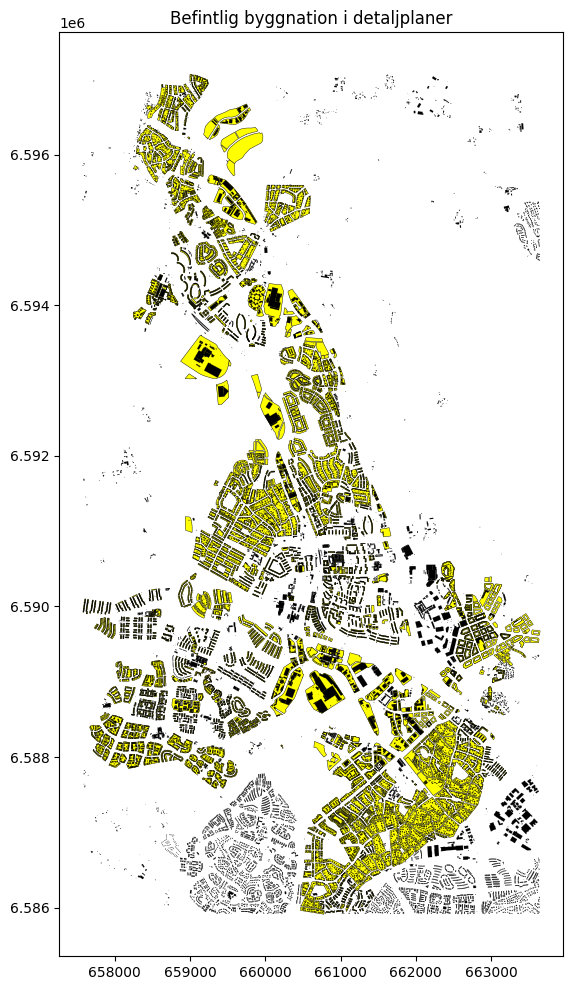

In [29]:
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, color="yellow", edgecolor='black', linewidth=0.3)
gdf_footprint.plot(ax=ax, color="black", edgecolor='black', linewidth=0.1)
ax.set_title(f"Befintlig byggnation i detaljplaner")
plt.show()

## Intersect and plot the exploited and unexploited areas

In [30]:
gdf = gdf[gdf["geometry"].area >= 10]  # Remove if the area is less than 10 kvm
gdf = gdf.reset_index(drop=True)
gdf["row_id"] = gdf.index
unexploited = gpd.overlay(gdf, gdf_footprint, how='difference', keep_geom_type=True)  # keep_geom_type=True
gdf = gdf[gdf["row_id"].isin(unexploited["row_id"])].copy()
gdf = gdf.reset_index(drop=True)

## Print the dataframe containing the important data

In [31]:
gdf["Objektidentitet"] = gdf["detaljplan"].apply(lambda x: x['objektidentitet'])
gdf['Detaljplan'] = gdf['detaljplan'].apply(lambda plan: f"{plan.get('namn')} {plan.get('beteckning')}")
plan_info = gdf[["Detaljplan", "title", "geometry", "Laga kraft", "Kommun", "Ladda ner plan", "Objektidentitet", "row_id"]].copy()
plan_info = plan_info.merge(gdf_detaljplan[['Objektidentitet', 'elevation']], on='Objektidentitet', how='left')
plan_info['Bestämmelse'] = gdf['planbestammelse'].apply(lambda x: x.get('kategori'))
plan_info["Area"] = gdf["geometry"].area.astype(int)
plan_info['Befintlig byggd area'] = ((1-(unexploited['geometry'].area / gdf["geometry"].area))*100).astype(int)
plan_info["Visa hos Lantmäteriet"] = plan_info.apply(
    lambda row: f"https://detaljplaner.lantmateriet.se/plats/3006/v2.0/?e={row.geometry.centroid.x}&n={row.geometry.centroid.y}", axis=1)

plan_info = plan_info.sort_values(["Befintlig byggd area", 'Area'], ascending=[True, False])
plan_info.reset_index(drop=True, inplace=True)

## Extract BTA, BYA and floors from egenskapsbestämmelser

In [32]:
gdf_bestammelser = gpd.overlay(gdf, gdf_egenskapsbestammelse, how="intersection", keep_geom_type=True)
gdf_bestammelser['area_bestammelse'] = gdf_bestammelser['geometry'].area

gdf_bestammelser['floors_weight'] = gdf_bestammelser['floors'] * gdf_bestammelser['area_bestammelse']
gdf_bestammelser['area_if_floors_valid'] = gdf_bestammelser['area_bestammelse'].where(gdf_bestammelser['floors'].notna(), 0)

gdf_bestammelser = gdf_bestammelser.groupby('row_id', as_index=False).agg({
    'BYA': 'sum',
    'BTA': 'sum',
    'floors_weight': 'sum',
    'area_if_floors_valid': 'sum'})

gdf_bestammelser['floors'] = gdf_bestammelser['floors_weight'] // gdf_bestammelser['area_if_floors_valid']
gdf_bestammelser = gdf_bestammelser[['row_id', 'BTA', 'BYA', 'floors']]

# Put the bruttoarea in the detail plan info
plan_info = plan_info.merge(gdf_bestammelser, on='row_id', how='left', suffixes=('_plan', '_egenskap'))

plan_info['Tillåten BYA (m²)'] = plan_info.apply(lambda row: min(row['BYA'], row['Area']) if not pd.isna(row['BYA']) else np.nan, axis=1)
plan_info['Antal våningar'] = plan_info['floors']

plan_info['Tillåten BTA (m²)'] = np.maximum(plan_info['BTA'].fillna(0), plan_info['Tillåten BYA (m²)'].fillna(0) * plan_info['floors'].fillna(0))
plan_info[['Tillåten BTA (m²)', 'Tillåten BYA (m²)', 'Antal våningar']] = plan_info[['Tillåten BTA (m²)', 'Tillåten BYA (m²)', 'floors']].replace(0, np.nan)

plan_info = plan_info.sort_values(["Befintlig byggd area", 'Area'], ascending=[True, False])
plan_info['Area (m²)'] = plan_info['Area'].apply(lambda x: int(x) if pd.notna(x) else x)
plan_info['Befintlig byggd area (%)'] = plan_info['Befintlig byggd area'].apply(lambda x: int(x) if pd.notna(x) else x)
plan_info['Tillåten BTA (m²)'] = plan_info['Tillåten BTA (m²)'].apply(lambda x: int(x) if pd.notna(x) else x)
plan_info['Tillåten BYA (m²)'] = plan_info['Tillåten BYA (m²)'].apply(lambda x: int(x) if pd.notna(x) else x)
plan_info['Antal våningar'] = plan_info['floors'].apply(lambda x: int(x) if pd.notna(x) else x)
plan_info.reset_index(drop=True, inplace=True)

c:\Users\isac.mjornell\OneDrive - Krook & Tjäder\Skrivbordet\Detaljplansanalys\.venv\Lib\site-packages\geopandas\geodataframe.py:1816: FutureWarning: `unary_union` returned None due to all-None GeoSeries. In future, `unary_union` will return 'GEOMETRYCOLLECTION EMPTY' instead.
  merged_geom = block.unary_union


In [33]:
plan_info_display = plan_info.copy()

plan_info_display['Area (m²)'] = plan_info_display['Area'].apply(lambda x: f"{int(x)} m&sup2" if pd.notna(x) else x)
plan_info_display['Befintlig byggd area (%)'] = plan_info_display['Befintlig byggd area'].apply(lambda x: f"{int(x)} %" if pd.notna(x) else x)
plan_info_display['Tillåten BTA (m²)'] = plan_info_display['Tillåten BTA (m²)'].apply(lambda x: f"{int(x)} m&sup2" if pd.notna(x) else x)
plan_info_display['Tillåten BYA (m²)'] = plan_info_display['Tillåten BYA (m²)'].apply(lambda x: f"{int(x)} m&sup2" if pd.notna(x) else x)
plan_info_display['Antal våningar'] = plan_info_display['floors'].apply(lambda x: f"{int(x)}" if pd.notna(x) else x)

plan_info_display['Ladda ner plan'] = plan_info["Ladda ner plan"].apply(lambda url: f'<a href="{url}" target="_blank">Ladda ner plan</a>')
plan_info_display["Visa hos Lantmäteriet"] = plan_info["Visa hos Lantmäteriet"].apply(lambda link: f'<a href="{link}" target="_blank">View vectorised plan</a>')
plan_info_display.reset_index(drop=True, inplace=True)
display(plan_info_display[['Detaljplan', 'Bestämmelse', 'Area (m²)', 'Befintlig byggd area (%)', 'Tillåten BTA (m²)', 'Tillåten BYA (m²)',
                           'Antal våningar', 'Laga kraft', 'Kommun', 'Visa hos Lantmäteriet', 'Ladda ner plan']].style)


,Detaljplan,Bestämmelse,Area (m²),Befintlig byggd area (%),Tillåten BTA (m²),Tillåten BYA (m²),Antal våningar,Laga kraft,Kommun,Visa hos Lantmäteriet,Ladda ner plan
0,Stäkets verksamhetsområde D 2016-09-23,Industri,92130 m²,0 %,181015 m²,45253 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
1,Stäkets verksamhetsområde D 2016-09-23,Industri,50401 m²,0 %,100803 m²,25200 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
2,Stäkets verksamhetsområde D 2016-09-23,Industri,25721 m²,0 %,51443 m²,12860 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
3,Polhem 1:1 och Jakobsberg 2:78 A 1932-10-25,Bostäder,19342 m²,0 %,162 m²,162 m²,1,1932,Järfälla kommun,View vectorised plan,Ladda ner plan
4,Bällstadalen D 2022-04-04,Verksamheter,19200 m²,0 %,nan,nan,12,2022,Järfälla kommun,View vectorised plan,Ladda ner plan
5,Ormbacka C fastigheterna Skälby 46:1 och 46:31 D 2023-09-25,Bostäder,19121 m²,0 %,25626 m²,8542 m²,3,2023,Järfälla kommun,View vectorised plan,Ladda ner plan
6,"Ormbacka norra, delplan 1 D 1988-06-15",Industri,16082 m²,0 %,48246 m²,16082 m²,3,1988,Järfälla kommun,View vectorised plan,Ladda ner plan
7,Återvinningscentral D 1996-09-10,Industri,15907 m²,0 %,nan,nan,nan,1996,Järfälla kommun,View vectorised plan,Ladda ner plan
8,Stäkets verksamhetsområde D 2016-09-23,Industri,14499 m²,0 %,28999 m²,7249 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
9,Skälby nr 3 och Stora Björkeby A 1927-04-12,Bostäder,14403 m²,0 %,nan,nan,nan,1927,Järfälla kommun,View vectorised plan,Ladda ner plan


## Calculate current BTA

In [34]:
gpkg_path = "building_heights.gpkg"

### Fetch height data from footprints

In [35]:
if not compute_current_BTA:
  print("skipping current BTA computations...")
elif os.path.exists(gpkg_path) and set(gdf_footprint['id']).issubset(set(gpd.read_file(gpkg_path, columns=['id'])['id'])):
  # Read the buildings from the gpkg file
  all_building_heights = gpd.read_file(gpkg_path)
  gdf_building_heights = all_building_heights[all_building_heights['id'].isin(gdf_footprint['id'])]
else:
  # Download geodataframe
  buildings_to_extract = gdf_detaljplan[gdf_detaljplan['Objektidentitet'].isin(plan_info['Objektidentitet'])]
  building_intersections = gpd.sjoin(buildings_to_extract, gdf_footprint, how="inner", predicate="intersects")
  matched_bounds = dtcc.Bounds(*building_intersections['geometry'].total_bounds)
  footprints = dtcc.download_footprints(bounds=matched_bounds)
  pointcloud = dtcc.download_pointcloud(bounds=matched_bounds)
  building_heights = dtcc.building_heights_from_pointcloud(footprints, pointcloud)

  # Put building heights in geodataframe
  id_list = [footprint.id for footprint in building_heights]
  ground_heights_list = [footprint.attributes['ground_height'] for footprint in building_heights]
  heights_list = [footprint.attributes['height'] for footprint in building_heights]
  polygons = [Polygon([(pt[0], pt[1]) for pt in list(footprint.geometry.values())[0].vertices]) for footprint in building_heights]
  gdf_building_heights = gpd.GeoDataFrame({'geometry': polygons, 'id': id_list,
                                          'ground_height': ground_heights_list, 'building_height': heights_list}, crs='EPSG:3006')

2025-08-26 09:12:45,940 [dtcc-data] [INFO] Starting the footprints download from dtcc source
2025-08-26 09:12:46,040 [dtcc-data] [INFO] File tile_648234_6583567.gpkg already in cache, skipping download.
2025-08-26 09:12:46,041 [dtcc-data] [INFO] File tile_648234_6593567.gpkg already in cache, skipping download.
2025-08-26 09:12:46,041 [dtcc-data] [INFO] File tile_658234_6583567.gpkg already in cache, skipping download.
2025-08-26 09:12:46,045 [dtcc-data] [INFO] File tile_658234_6593567.gpkg already in cache, skipping download.
2025-08-26 09:12:46,047 [dtcc-data] [INFO] All downloads finished.
2025-08-26 09:12:46,047 [dtcc io2] [INFO] Loading city (City) from C:\Users\isac.mjornell\AppData\Local\dtcc-data\dtcc-data\Cache\downloaded-gpkg\tile_648234_6583567.gpkg
2025-08-26 09:12:46,061 [dtcc io2] [INFO] Reading 9584 geometries from C:\Users\isac.mjornell\AppData\Local\dtcc-data\dtcc-data\Cache\downloaded-gpkg\tile_648234_6583567.gpkg
2025-08-26 09:12:47,162 [dtcc io2] [INFO] Loaded 1789 

### Append downloaded buildings to file

In [36]:
# existing_ids = gpd.read_file(gpkg_path, columns=['id'])['id'].tolist()
# records_to_append = gdf_building_heights[~gdf_building_heights['id'].isin(existing_ids)]
# if not records_to_append.empty:
#     records_to_append.to_file(gpkg_path, driver="GPKG", mode="a")

### Caculate and insert in dataframes

In [37]:
if not compute_current_BTA:
  print("skipping current BTA computations...")
else:
  overlay = gpd.overlay(plan_info, gdf_building_heights, how='intersection', keep_geom_type=True)
  overlay['Befintlig BTA (m²)'] = overlay['geometry'].area * overlay['building_height'] // 3  # Assuming 3m per floor
  current_BTA = overlay.groupby('row_id')['Befintlig BTA (m²)'].sum()
  if "Befintlig BTA (m²)" not in plan_info.columns:
      plan_info = plan_info.merge(current_BTA, on='row_id', how='left').fillna({'Befintlig BTA (m²)': 0})
      plan_info['Befintlig BTA (m²)'] = plan_info['Befintlig BTA (m²)'].apply(lambda x: int(x) if pd.notna(x) else x)
      plan_info_display = plan_info_display.merge(current_BTA, on='row_id', how='left').fillna({'Befintlig BTA (m²)': 0})
      plan_info_display['Befintlig BTA (m²)'] = plan_info_display['Befintlig BTA (m²)'].apply(lambda x: f"{int(x)} m&sup2" if pd.notna(x) else x)

### Display dataframe

In [38]:
if not compute_current_BTA:
  print("skipping current BTA computations...")
else:
  display(plan_info_display[['Detaljplan', 'Bestämmelse', 'Area (m²)', 'Befintlig byggd area (%)', 'Befintlig BTA (m²)', 'Tillåten BTA (m²)',
                            'Tillåten BYA (m²)', 'Antal våningar', 'Laga kraft', 'Kommun', 'Visa hos Lantmäteriet', 'Ladda ner plan']].style)

,Detaljplan,Bestämmelse,Area (m²),Befintlig byggd area (%),Befintlig BTA (m²),Tillåten BTA (m²),Tillåten BYA (m²),Antal våningar,Laga kraft,Kommun,Visa hos Lantmäteriet,Ladda ner plan
0,Stäkets verksamhetsområde D 2016-09-23,Industri,92130 m²,0 %,0 m²,181015 m²,45253 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
1,Stäkets verksamhetsområde D 2016-09-23,Industri,50401 m²,0 %,11 m²,100803 m²,25200 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
2,Stäkets verksamhetsområde D 2016-09-23,Industri,25721 m²,0 %,0 m²,51443 m²,12860 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
3,Polhem 1:1 och Jakobsberg 2:78 A 1932-10-25,Bostäder,19342 m²,0 %,0 m²,162 m²,162 m²,1,1932,Järfälla kommun,View vectorised plan,Ladda ner plan
4,Bällstadalen D 2022-04-04,Verksamheter,19200 m²,0 %,0 m²,nan,nan,12,2022,Järfälla kommun,View vectorised plan,Ladda ner plan
5,Ormbacka C fastigheterna Skälby 46:1 och 46:31 D 2023-09-25,Bostäder,19121 m²,0 %,0 m²,25626 m²,8542 m²,3,2023,Järfälla kommun,View vectorised plan,Ladda ner plan
6,"Ormbacka norra, delplan 1 D 1988-06-15",Industri,16082 m²,0 %,0 m²,48246 m²,16082 m²,3,1988,Järfälla kommun,View vectorised plan,Ladda ner plan
7,Återvinningscentral D 1996-09-10,Industri,15907 m²,0 %,131 m²,nan,nan,nan,1996,Järfälla kommun,View vectorised plan,Ladda ner plan
8,Stäkets verksamhetsområde D 2016-09-23,Industri,14499 m²,0 %,0 m²,28999 m²,7249 m²,4,2016,Järfälla kommun,View vectorised plan,Ladda ner plan
9,Skälby nr 3 och Stora Björkeby A 1927-04-12,Bostäder,14403 m²,0 %,0 m²,nan,nan,nan,1927,Järfälla kommun,View vectorised plan,Ladda ner plan


# Export to Kepler

## Detail plans

In [39]:
if not compute_current_BTA:
    gdf_wgs84 = plan_info[['geometry', 'Detaljplan', 'Bestämmelse', 'Area (m²)', 'Befintlig byggd area (%)', 'Tillåten BTA (m²)', 
                        'Tillåten BYA (m²)', 'Antal våningar', 'Laga kraft', 'Kommun', 'Visa hos Lantmäteriet', 'Ladda ner plan']].to_crs(epsg=4326)
else:
    gdf_wgs84 = plan_info[['geometry', 'Detaljplan', 'Bestämmelse', 'Area (m²)', 'Befintlig byggd area (%)', 'Befintlig BTA (m²)', 'Tillåten BTA (m²)',
                        'Tillåten BYA (m²)', 'Antal våningar', 'Laga kraft', 'Kommun', 'Visa hos Lantmäteriet', 'Ladda ner plan']].to_crs(epsg=4326)
gdf_wgs84 = gdf_wgs84[gdf_wgs84.is_valid]

## Export bounding box

In [40]:
bbox_polygon = box(bbox[0], bbox[1], bbox[2], bbox[3])
gdf_bbox = gpd.GeoDataFrame({'geometry': [bbox_polygon]}, crs='EPSG:3006')
gdf_bbox = gdf_bbox.to_crs(epsg=4326)

## Create folder for storing the data

In [41]:
base = Path("Zoning plan locations")
folder = base.joinpath(location_name)
folder.mkdir(parents=True, exist_ok=True)

## Export data to files

In [42]:
gdf_wgs84.to_file(os.path.join(folder, f"{location_name}_detaljplaner.geojson"), driver="GeoJSON")
gdf_bbox.to_file(os.path.join(folder, f"{location_name}_område.geojson"), driver="GeoJSON")

## Kepler map

### Save configuration file

In [43]:
# with open("kepler_config.json", 'w') as f:
#     json.dump(m.config, f, indent=2)

### Load configuration file

In [44]:
with open("kepler_config.json") as f:
    config = json.load(f)

### Display map

In [45]:
minx, miny, maxx, maxy = gdf_bbox.total_bounds
center_lon = (minx + maxx) / 2
center_lat = (miny + maxy) / 2
new_zoom = 9 - np.log(max(maxx - minx, maxy - miny))

config["config"]["mapState"].update({
    "latitude":  center_lat,
    "longitude": center_lon,
    "zoom":      new_zoom,
})

m = KeplerGl(data={f"detaljplaner.geojson": gdf_wgs84, f"område.geojson": gdf_bbox}, config=config, show_docs=False)
display(m)

c:\Users\isac.mjornell\OneDrive - Krook & Tjäder\Skrivbordet\Detaljplansanalys\.venv\Lib\site-packages\jupyter_client\session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [{'dataId': ['detaljplaner.geojson'], 'id…

In [46]:
m.save_to_html(read_only=False, center_map=True, file_name=os.path.join(folder, f'{location_name}.html'))

Map saved to Zoning plan locations\Järfälla\Järfälla.html!


## Open Kepler file

In [47]:
filepath = os.path.join(folder, f"{location_name}.html")
! start "" "{filepath}"

# --------------------------------------
# End of notebook